In [1]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST, QMNIST, KMNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

import torchaudio.transforms as T
import math   
from src.dataset import NSynth
import torch
from src.diffusion import *

mnist_datasets_path = r'C:\Users\Articuno\Desktop\TFG-info\data\mnist'

diff_mnist_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\diff_mnist.pth'
diff_sch_mnist_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\sch_diff_mnist.pth'

diff_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\diff.pth'
diff_sch_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\sch_diff.pth'

temp_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\temp.pth'
sch_temp_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\sch_temp.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device('cpu')

In [2]:
# STFT transform
sample_rate = 16000
n_fft = 1500
hop_length = 250
win_length = n_fft
stft_transform = T.Spectrogram(
    n_fft=n_fft, win_length=win_length, hop_length=hop_length,
    power=2.0, onesided=False, center=False
).to(device)

In [ ]:
import os
import time

def train(
    model, 
    epochs=1000, 
    batch_size=16, 
    lr=1e-3, 
    model_path=None,
    sch_path=None, 
    dataset=NSynth('training'), 
    v_dataset=NSynth('validation'),
    verb=False,
    verb_batch=False
):
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,  pin_memory=True)
    valid_loader = DataLoader(v_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler()
    scheduler = Scheduler(num_epochs=epochs, device=device).to(device)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    diffuser = Diffuser(model, scheduler).to(device)

    
    mse_loss = nn.MSELoss()
    best_loss = 1
    losses = []
    valid_losses = []
    
    for epoch in range(epochs):
        start_time = time.time() 
        b_idx = 0
        epoch_loss = 0
        for x, _ in train_loader:
            b_idx += 1        
            x = x.to(device)
            batch_size = x.size(0)
            t = torch.randint(0, epochs, (batch_size,), device=device)

            # with torch.cuda.amp.autocast(dtype=torch.bfloat16): # OPTIMIZACION FLOAT 32
                # print(f"mag: {mag.shape}, sin: {sin.shape}, cos: {cos.shape}, x: {x.shape}")
            z, e = diffuser(x, t)
            e_pred = model(z, t)
            if e_pred.shape != e.shape: # TODO borrar esto es debug
                print('error en los tamaños')

            loss = mse_loss(e_pred, e)
            epoch_loss += loss.item()

            # NO optimizado
            # z, e = diffuser(x, t)
            # e_pred = model(z, t)

            loss = mse_loss(e_pred, e)

            # No optimizado
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step() # LEARNING SCHEDULER

            
            
            # scaler.scale(loss).backward() # TODO no se si la funcion de loss es la mas optima para el caso
            # scaler.step(optimizer)
            # scaler.update()
            
            if verb_batch:
                if b_idx %10 == 0:
                    _t = time.time() - start_time
                    print(f'tiempo en {b_idx} batchs: {_t:.5f} \t| media de tiempo por batch: {_t/b_idx:.5f} \t| media de loss: {epoch_loss/b_idx:.5f}')

            
        losses.append(epoch_loss/b_idx)
        
        # VALIDATION:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            val_batches = 0
            for x, _ in valid_loader:
                x = x.to(device)
                batch_size = x.size(0)
                t = torch.randint(0, epochs, (batch_size,), device=device)

                z, e = diffuser(x, t)
                e_pred = model(z, t)
                val_loss += mse_loss(e_pred, e).item()
                val_batches += 1
        
        valid_losses.append(val_loss / val_batches if val_batches > 0 else 0)

        if epoch % 10 == 0 or epochs < 100:
            if verb:
                _t = time.time() - start_time
                print(f"Epoch {epoch}, Loss: {loss.item()}, Valid loss: {valid_losses[-1]}, time: {time.time() - start_time}, avg wave time: {_t/(batch_size*b_idx)}")
          
            
        if epoch_loss/b_idx < best_loss:
            # best_loss = loss.item()
            if model_path is not None:
                torch.save(model.state_dict(), model_path)
                torch.save(scheduler.state_dict(), sch_path)
                # if verb:
                    # print(f"Model temporally saved at epoch {epoch} with loss {best_loss}")
            else:
                torch.save(model.state_dict(), temp_path)
                torch.save(scheduler.state_dict(), sch_temp_path)
                # if verb:
                    # print(f"Model saved at epoch {epoch} with loss {best_loss}")
    
    if model_path is not None:
        model.load_state_dict(torch.load(model_path))
        scheduler.load_state_dict(torch.load(sch_path))
    else:
        model.load_state_dict(torch.load(temp_path))
        scheduler.load_state_dict(torch.load(sch_temp_path))

        # eliminar temp?
        
    print("Training completed., best loss:", best_loss)
    
    return model, scheduler, losses
    

In [4]:
@torch.no_grad()
def sample_images(model, scheduler, num_images=4, image_size=(1, 28, 28)):
    model.eval()

    x = torch.randn(num_images, *image_size, device=device)
    T = scheduler.beta.size(0)

    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar

    for t in reversed(range(T)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        # predicción de ruido
        e_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        
        # beta_t = beta_t.view(1,1,1,1)
        # alpha_t = alpha_t.view(1,1,1,1)
        # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


        # Coeficientes DDPM
        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

        mu = coef1 * (x - coef2 * e_pred)

        if t > 0:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mu + sigma_t * noise
        else:
            x = mu

    x = x.clamp(0, 1).cpu()

    # Mostrar imágenes
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*2, 2))
    for i in range(num_images):
        axes[i].imshow(x[i, 0], cmap='gray')
        axes[i].axis('off')
    plt.show()

    return x

@torch.no_grad()
def remove_noise(model, scheduler, image_size=(1, 28, 28), x=None, alpha=0):
    model.eval()
    if x is None:
        x = torch.randn(1, *image_size, device=device)
        alpha = 1

    # Guardar imagen original
    x_original = x.clone().cpu()

    # Añadir ruido
    noise = torch.randn(1, *image_size, device=device) * (1 - alpha)
    x_noisy = x * alpha + noise
    x = x_noisy.clone()  # este será el tensor que pasaremos al DDPM

    T = scheduler.beta.size(0)
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar

    for t in reversed(range(T)):
        t_batch = torch.full((1,), t, device=device, dtype=torch.long)
        e_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)
        mu = coef1 * (x - coef2 * e_pred)

        if t > 0:
            noise_step = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mu + sigma_t * noise_step
        else:
            x = mu

    x_denoised = x.clamp(0, 1).cpu()

    # Mostrar imágenes: original, con ruido, denoised
    fig, axes = plt.subplots(1, 3, figsize=(6, 2))
    axes[0].imshow(x_original[0, 0], cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(x_noisy[0, 0].cpu(), cmap='gray')
    axes[1].set_title('Noisy')
    axes[1].axis('off')

    axes[2].imshow(x_denoised[0, 0], cmap='gray')
    axes[2].set_title('Denoised')
    axes[2].axis('off')

    plt.show()

    return x_denoised



In [5]:
# TRAIN SETUP
batch_size = 2048 //2
learning_rate = 1e-4
epochs = 10

# MODEL SETUP
input_height = 28
input_width = 28

input_size = (input_height, input_width)
emb_dim = 128
norm_groups = 8

# layers
sin = sout = c = 128//4  # canal base, reducido para no explotar memoria
# TODO hacer que el tamaño dependa de n_ftt
# down_layers = [  
#     DummyLayer(c,    c*2,  norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c canales
#     DummyLayer(c*2,  c*4,  norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c*2 canales
#     DummyLayer(c*4,  c*8,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c*4 canales
#     # DummyLayer(c*8,  c*16, norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c*8 canales
# ]



# up_layers = [ # TODO Podria hacer esto con stride = -2? o coger y hacer que si el stride es negativo, aumente manualmente 
#     # DummyLayer(c*16 + c*8,  c*8, norm_groups, emb_dim, stride=-2).to(device),
#     DummyLayer(c*8  + c*4,  c*4, norm_groups, emb_dim, stride=-1).to(device),
#     DummyLayer(c*4  + c*2,  c*2, norm_groups, emb_dim, stride=-2).to(device),
#     DummyLayer(c*2  + c,    c,   norm_groups, emb_dim, stride=-2).to(device),
# ]

# SKIP = fALSE
down_layers = [  
    DummyLayer(c,    c*2,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c canales
    DummyLayer(c*2,  c*4,  norm_groups, emb_dim, skip=False, stride=1).to(device),  # skip: c*2 canales
    DummyLayer(c*4,  c*8,  norm_groups, emb_dim, skip=False, stride=1).to(device),  # skip: c*4 canales
    # DummyLayer(c*8,  c*16, norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c*8 canales
]

bottleneck = DummyLayer(c*8, c*8, norm_groups, emb_dim).to(device)

up_layers = [
    # DummyLayer(c*16 + c*8,  c*8, norm_groups, emb_dim, stride=-2).to(device),
    DummyLayer(c*8,  c*4, norm_groups, emb_dim, stride=-1).to(device),
    DummyLayer(c*4,  c*2, norm_groups, emb_dim, stride=-1).to(device),
    DummyLayer(c*2 + c,    c,   norm_groups, emb_dim, stride=-1).to(device),
]


# up_layers = [
#     DummyLayer(c*16 + c*8, c*8, norm_groups, emb_dim).to(device),
#     DummyLayer(c*8  + c*4, c*4, norm_groups, emb_dim).to(device),
#     DummyLayer(c*4  + c*2, c*2, norm_groups, emb_dim).to(device),
#     DummyLayer(c*2  + c,   c,   norm_groups, emb_dim).to(device),
# ]

# embeder
embedder = Embeder(num_epochs=epochs, embed_dim=emb_dim, device=device).to(device)

# scheduler
scheduler = Scheduler(num_epochs=epochs, device=device).to(device)

# model
model = DiffusionModel(
    layer_channels=(sin, sout),
    norm_groups=norm_groups,
    up_layers=up_layers,
    down_layers=down_layers,
    bottleneck=bottleneck,
    embedder=embedder, 
    input_channels=1,
    output_channels=1,
).to(device)


In [ ]:
# %%time
model, scheduler, losses = train(
    model, 
    epochs=epochs,
    batch_size=batch_size, 
    lr=learning_rate, 
    model_path=diff_mnist_model_path, 
    sch_path=diff_sch_mnist_model_path,
    dataset= QMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor()),
    verb=True,
    verb_batch=False
)
plt.plot(losses)
print(f'learning_rate: {learning_rate}')
print(f'num_chaneles (c) {c}')

Epoch 0, Loss: 0.5710981488227844, time: 42.741358280181885, avg image time: 0.0011914963838141695


# ^^ PENDEJO NO APRENDE NADA >:(
creo que es por la movida de los skips

In [ ]:
# model, scheduler, losses = createObjects(num_epochs, norm_groups, sin, sout)
# scheduler.load_state_dict(torch.load(diff_sch_mnist_model_path))
# model.load_state_dict(torch.load(diff_mnist_model_path))


In [ ]:
# print('Losses:')
# plt.plot(losses)

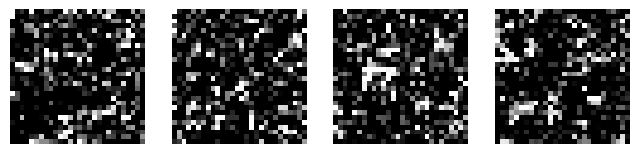

In [ ]:
_ = sample_images(model, scheduler, num_images=4, image_size=(1, 28, 28))

In [ ]:
from random import randint
mnist_ds = QMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())
x, _ = mnist_ds[randint(1, len(mnist_ds))]
noise = torch.randn_like(x)
x = x.unsqueeze(0).to(device)  # agregar dimensión batch y mover a device
_ = remove_noise(model, scheduler, (1, 28, 28), x, 2)

: 

<!-- Problemas: a veces sale muy poco loss y es porque sale todo en negro :/ -->
